question: import numpy as np 
from sklearn.datasets import make_classification 

from sklearn.model_selection import train_test_split

 from sklearn.linear_model import LogisticRegression 

from sklearn.metrics import precision_recall_curve, auc

 import matplotlib.pyplot as plt

 # Step 1: Generate an imbalanced dataset

 X, y = make_classification(     n_samples=1000,     n_features=20,     n_informative=2,     n_redundant=10,     n_clusters_per_class=1,     weights=[0.9, 0.1],  # 90% of class 0, 10% of class 1     flip_y=0,     random_state=42 )

 

You are provided with a labeled dataset containing features and target variables.. Your task is to develop an AI/ML model, train it using the dataset, and evaluate its performance using appropriate metrics. Create your questions and conclusion.

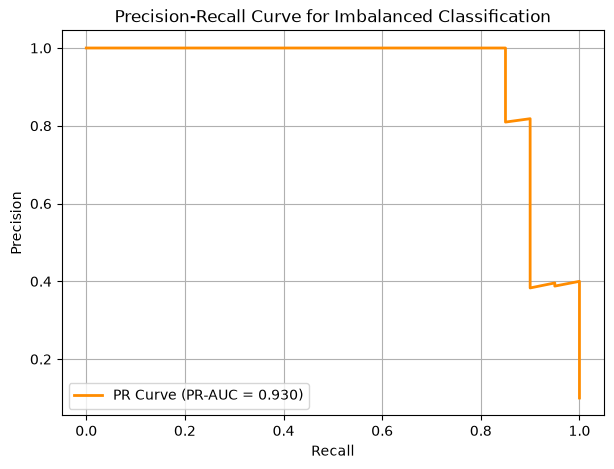

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.99      0.99       180
           1       0.94      0.85      0.89        20

    accuracy                           0.98       200
   macro avg       0.96      0.92      0.94       200
weighted avg       0.98      0.98      0.98       200

Area Under Precision-Recall Curve (PR-AUC): 0.9299


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_recall_curve, auc, classification_report, confusion_matrix

# Step 1: Generate an imbalanced dataset
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=2,
    n_redundant=10,
    n_clusters_per_class=1,
    weights=[0.9, 0.1],  # 90% class 0, 10% class 1
    flip_y=0,
    random_state=42
)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)


y_pred_proba = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)


precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)


plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color="darkorange", lw=2, label=f"PR Curve (PR-AUC = {pr_auc:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Imbalanced Classification")
plt.legend(loc="lower left")
plt.grid(True)
plt.show()

# Print Evaluation Metrics
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Area Under Precision-Recall Curve (PR-AUC):", round(pr_auc, 4)) 


Question 1: Why is standard Accuracy an unsuitable evaluation metric for this dataset?

Answer: With a $90:10$ class ratio, a dummy classifier predicting the majority class (Class 0) every time would achieve $90\%$ accuracy while failing completely to detect the minority class (Class 1).

Question 2: Why is Precision-Recall AUC preferred over ROC-AUC for imbalanced datasets?

Answer: ROC-AUC includes True Negative Rate (Specificity), which remains artificially high in imbalanced datasets due to the abundance of majority class samples. PR-AUC focuses specifically on the minority class performance (Precision and Recall).

Question 3: How can model performance on the minority class be further improved?

Answer: Techniques such as SMOTE (oversampling minority class), adjusting the decision threshold, setting class_weight='balanced', or using tree-based ensemble algorithms like Random Forest or XGBoost.